In [32]:
#@title 🧰 Install pytka library and other requirements
from IPython.display import clear_output

clear_cell_output = True #@param {type:'boolean'}

!pip install -i https://test.pypi.org/simple/ --no-deps coolbox
!pip install dagshub
!pip install mlflow
!pip install optuna

if clear_cell_output:
  clear_output()
  print("All libraries installed successfully")


All libraries installed successfully


In [1]:
#@title 🛠️ Global imports

import pandas as pd
import plotly.express as px
import optuna

In [ ]:
# import sys
# import os

# # Add the path to the library directory
# sys.path.append('C:\\Users\\Marek\\PycharmProjects\\coolbox\\.venv\\Lib\\site-packages')

# import sys
# print(sys.path)

!pip uninstall pytka
!pip install -e .



# 🪀 Local setup for development 

In [2]:
!pip3 install -e . 

Obtaining file:///C:/Users/Marek/PycharmProjects/coolbox/pytka
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for pytka (pyproject.toml): started
  Building editable for pytka (pyproject.toml): finished with status 'done'
  Created wheel for pytka: filename=pytka-0.0.7-py3-none-any.whl size=2684 sha256=3d88b69e200385f55d85a964b928d22947a285481371fadf125cb2b36ccfebeb
  Stored in directory: C:\Users\Marek\AppData\Local\Temp


[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 📋 DataFrame helpers

In [16]:
#@title 🛠️ Imports
from pytka.dataframes import dummify_dataframe, remove_column_if_present, optimize_dataframe, remove_dataframes, text_input_to_numericals, df_memory_usage

Imports done


In [5]:
#@title 😀 dummify_dataframe
data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia'],
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania'],
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155]
}

# Create the DataFrame
df = pd.DataFrame(data)

dummified_df = dummify_dataframe(df, dummy_columns = ['country', 'continent'], verbose = True)

print(f"""Shape before dummification: {df.shape}""")
print(f"""Shape after dummification: {dummified_df.shape}""")
dummified_df

Processing feature country
Processing feature continent
Shape before dummification: (10, 3)
Shape after dummification: (10, 16)


,gdp,country_Australia,country_Brazil,country_Canada,country_China,country_France,country_Germany,country_India,country_Japan,country_UK,country_USA,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
0,21137518,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
1,1647000,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
2,3845630,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,2715518,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
4,2825208,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
5,14342903,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
6,5081770,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False
7,2875142,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
8,1444731,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
9,1330155,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [6]:
#@title 🗑️ remove_column_if_present
data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia'],
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania'],
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155]
}

# Create the DataFrame
df = pd.DataFrame(data)
df_without_country = df.copy()

# Removing actual column
print(f"""Columns before removal: {df_without_country.columns}""")
remove_column_if_present(df_without_country, 'country')
print(f"""Columns after removal: {df_without_country.columns}""")
df_without_country

Columns before removal: Index(['country', 'continent', 'gdp'], dtype='object')
Columns after removal: Index(['continent', 'gdp'], dtype='object')


,continent,gdp
0,North America,21137518
1,North America,1647000
2,Europe,3845630
3,Europe,2715518
4,Europe,2825208
5,Asia,14342903
6,Asia,5081770
7,Asia,2875142
8,South America,1444731
9,Oceania,1330155


In [7]:
#@title 🌡️ optimize_dataframe

data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia']*10000,
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania']*10000,
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155]*10000,
    'year': [2024, 2023, 2022, 2021, 2020, 2019, 2019, 2018, 2017, 2016] * 10000
}

# Create the DataFrame
df = pd.DataFrame(data)

# Optimize the DataFrame

optimized_df = optimize_dataframe(df)
print(f"""Dtypes before optimization: {df.dtypes}""")
optimized_df
print(f"""Dtypes before optimization: {optimized_df.dtypes}""")

Initial memory usage: 12.11 MB
Final memory usage: 11.16 MB
Dtypes before optimization: country      object
continent    object
gdp           int64
year          int64
dtype: object
Dtypes before optimization: country      object
continent    object
gdp           int32
year          int16
dtype: object


In [12]:
#@title 🚮 remove_dataframes

data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia'],
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania'],
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155]
}

# Create two DataFrames
df = pd.DataFrame(data)
df_two = pd.DataFrame(data)

# Remove both and verify if they are there:
remove_dataframes(df_dict={'df': df, 'df_two': df_two})

Initial memory usage of DataFramedf: 0.00 MB
DataFrame df not present in the runtime
Initial memory usage of DataFramedf_two: 0.00 MB
DataFrame df_two not present in the runtime


In [15]:
#@title 📰 text_input_to_numericals

data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia'],
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania'],
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155]
}

# Create the DataFrame
df = pd.DataFrame(data)

# Convert text inputs to numericals, store the mappings 
dataframe, mappings = text_input_to_numericals(df, columns = ['country', 'continent'])

dataframe
print(mappings)

{'country': {'USA': 0, 'Canada': 1, 'Germany': 2, 'France': 3, 'UK': 4, 'China': 5, 'Japan': 6, 'India': 7, 'Brazil': 8, 'Australia': 9}, 'continent': {'North America': 0, 'Europe': 1, 'Asia': 2, 'South America': 3, 'Oceania': 4}}


C:\Users\Marek\PycharmProjects\coolbox\pytka\src\pytka\dataframes.py:207: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



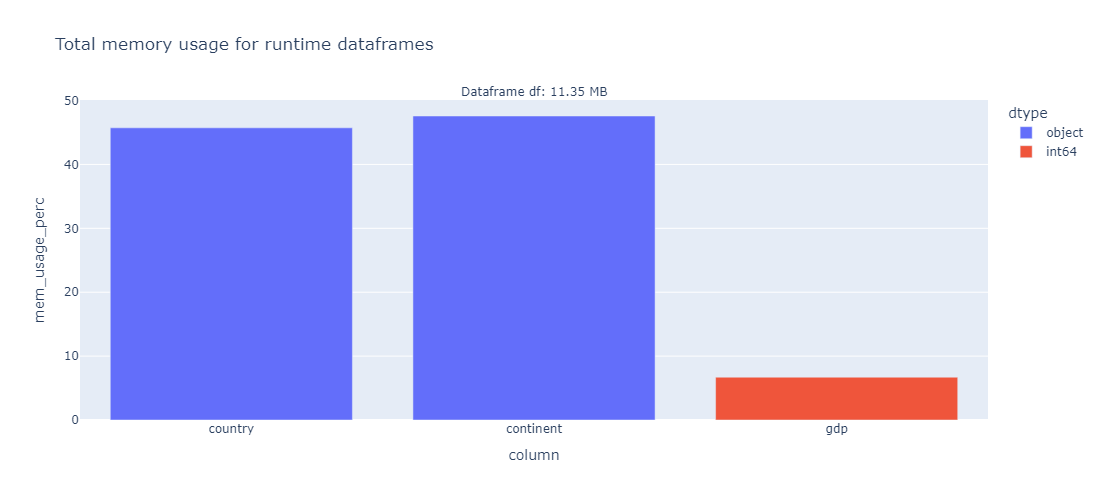

In [23]:
#@title df_memory_usage

data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia'] * 10000,
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania'] * 10000,
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155] * 10000
}

# Create the DataFrame
df = pd.DataFrame(data)

# Just plot, avoid storing the underlaying dataframe 

_ = df_memory_usage({'df': df}, plot_height=500, plot_width=1000)


# 📖 NLP helpers

In [24]:
#@title 🛠️ Imports
import nltk
nltk.download('words')
from nltk.corpus import words
from pytka.nlp import string_to_lowercase_word_list, calculate_english_word_ratio, avg_word_length, avg_sentence_word_length, tfidf_vectorize_sequences, describe_tfidf_vectorizer

# Prompt base for the functions below

prompts = ["Hello, this is a test sentence.",
        "Helo, dis is a test sentens",
        "Bonjour, ceci est une phrase de test.",
        "12345 !@#$%",
        "Good morning. How are you?",
        "Nevertheless something makes problems. Unfortunately, long sentences are very exhaustive.",
        "Nevertheless something makes problems.",
        "Nevertheless something make problem." # Lemmatize reminder example
        ]



[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Marek\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\words.zip.
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Marek\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


In [25]:
#@title 🔠 string_to_lowercase_word_list

for prompt in prompts:
  print(f"""Initial prompt: {prompt}\nOutput list: {string_to_lowercase_word_list(prompt)}\n""")


Initial prompt: Hello, this is a test sentence.
Output list: ['hello', 'this', 'is', 'a', 'test', 'sentence']

Initial prompt: Helo, dis is a test sentens
Output list: ['helo', 'dis', 'is', 'a', 'test', 'sentens']

Initial prompt: Bonjour, ceci est une phrase de test.
Output list: ['bonjour', 'ceci', 'est', 'une', 'phrase', 'de', 'test']

Initial prompt: 12345 !@#$%
Output list: ['12345']

Initial prompt: Good morning. How are you?
Output list: ['good', 'morning', 'how', 'are', 'you']

Initial prompt: Nevertheless something makes problems. Unfortunately, long sentences are very exhaustive.
Output list: ['nevertheless', 'something', 'makes', 'problems', 'unfortunately', 'long', 'sentences', 'are', 'very', 'exhaustive']

Initial prompt: Nevertheless something makes problems.
Output list: ['nevertheless', 'something', 'makes', 'problems']

Initial prompt: Nevertheless something make problem.
Output list: ['nevertheless', 'something', 'make', 'problem']



In [26]:
#@title 👅 calculate_english_word_ratio

for prompt in prompts:
    try:
        ratio = calculate_english_word_ratio(prompt)
        print(f"Prompt: '{prompt}'\nEnglish Word Ratio: {ratio:.2f}\n")
    except ValueError as e:
        print(f"Prompt: '{prompt}'\nError: {e}\n")

Prompt: 'Hello, this is a test sentence.'
English Word Ratio: 1.00

Prompt: 'Helo, dis is a test sentens'
Error: Improper sentence - it does not end with end of sentence characters

Prompt: 'Bonjour, ceci est une phrase de test.'
English Word Ratio: 0.43

Prompt: '12345 !@#$%'
Error: Improper sentence - it does not end with end of sentence characters

Prompt: 'Good morning. How are you?'
English Word Ratio: 1.00

Prompt: 'Nevertheless something makes problems. Unfortunately, long sentences are very exhaustive.'
Error: Improper sentence - it some end of sentence characters are present more than once

Prompt: 'Nevertheless something makes problems.'
English Word Ratio: 0.50

Prompt: 'Nevertheless something make problem.'
English Word Ratio: 1.00



In [27]:
#@title ⛓️‍💥 avg_word_length [AWL]

for prompt in prompts:
  print(f"""Initial prompt: {prompt} || AWL: {avg_word_length(prompt)}""")



Initial prompt: Hello, this is a test sentence. || AWL: 4.0
Initial prompt: Helo, dis is a test sentens || AWL: 3.5
Initial prompt: Bonjour, ceci est une phrase de test. || AWL: 4.142857142857143
Initial prompt: 12345 !@#$% || AWL: 5.0
Initial prompt: Good morning. How are you? || AWL: 4.0
Initial prompt: Nevertheless something makes problems. Unfortunately, long sentences are very exhaustive. || AWL: 7.7
Initial prompt: Nevertheless something makes problems. || AWL: 8.5
Initial prompt: Nevertheless something make problem. || AWL: 8.0


In [28]:
#@title ⛓️ avg_sentence_word_length [ASWL]

for prompt in prompts:
  print(f"""{prompt} || ASWL: {avg_sentence_word_length(prompt)}\n""")


Hello, this is a test sentence. || ASWL: 4.0

Helo, dis is a test sentens || ASWL: 3.5

Bonjour, ceci est une phrase de test. || ASWL: 4.142857142857143

12345 !@#$% || ASWL: 2.5

Good morning. How are you? || ASWL: 4.25

Nevertheless something makes problems. Unfortunately, long sentences are very exhaustive. || ASWL: 7.833333333333334

Nevertheless something makes problems. || ASWL: 8.5

Nevertheless something make problem. || ASWL: 8.0



In [29]:
#@title 🟦 tfidf_vectorize_sequences

# Create dummy datasets
train_data = pd.DataFrame({
    'field1': ['This is a test sentence.', 'Another test sentence.', 'More test data here.'],
    'field2': ['Dummy text for field two.', 'Another dummy text.', 'Yet another text entry.']
})

test_data = pd.DataFrame({
    'field1': ['Test sentence for validation.', 'Yet another sentence.'],
    'field2': ['Validation text for second field.', 'Another validation entry.']
})

# Combine datasets into a list
datasets = [train_data, test_data]

# Define TF-IDF vectorizer parameters
tfidf_vectorizer_params = {
    'max_features': 100,
    'stop_words': 'english'
}

# Define fields with sequences
fields_with_sequences = ['field1', 'field2']

# Define number of components for SVD
svd_n_components = 2

# Dummy process function to clean/prepare text
def dummy_process_fn(text):
    return text.lower()

# Now you can call your function with these parameters
train_features, test_features, reduced_matrix, tfidf_matrix, tfidf_vectorizer = tfidf_vectorize_sequences(
    datasets=datasets,
    tfidf_vectorizer_params=tfidf_vectorizer_params,
    fields_with_sequences=fields_with_sequences,
    svd_n_components=svd_n_components,
    process_fn=dummy_process_fn
)

# Print the results for verification
print("\n")
print("Train features:\n")
print(train_features)
print("\nTest features:\n")
print(test_features)
print("\nReduced matrix:\n")
print(reduced_matrix)
print("\nTF-IDF matrix:\n")
print(tfidf_matrix)
print("\nTF-IDF vectorizer:\n")
print(tfidf_vectorizer)


Started TFIDF vectorization at: 2024-08-02 18:44:47.856960
TFIDF vectorizer fitted successfully
TruncatedSVD applied properly
Vectorization execution time: 0.07008410000707954s


Train features:

   svd_field1_0  svd_field2_0  svd_field1_1  svd_field2_1  similarity_pa  \
0      0.961683      0.053473     -0.131483      0.813429       0.979058   
1      0.961683      0.043156     -0.131483      0.758047       0.999976   
2      0.417175      0.072599     -0.059983      0.684365      -0.077086   

   similarity_pb  euclidean_pa  euclidean_pb  laplacian_pa  laplacian_pb  
0      -0.078928      0.207108      1.278654      0.874425      0.404935  
1      -0.030188      0.206577      1.206681      0.892234      0.426362  
2       0.075979      0.946112      0.770009      0.538721      0.609204  

Test features:

   svd_field1_0  svd_field2_0  svd_field1_1  svd_field2_1  similarity_pa  \
0      0.886149      0.147039      0.061360      0.661085       0.999976   
1      0.756360      0.183955 

In [32]:
#@title 👻 describe_tfidf_vectorizer
if 'tfidf_vectorizer' not in globals():
    print('Run a cell with `tfidf_vectorize_sequences` function first')
else:
    describe_tfidf_vectorizer(tfidf_vectorizer, tfidf_matrix)

Total words: 9
Initial matrix shape: (10, 9)
Truncated matrix shape: (0, 0)

Examples of (document/word) pairs:

  (np.int32(0), np.int32(6))	0.7071067811865475
  (np.int32(0), np.int32(5))	0.7071067811865475


# 🍫 Features

In [89]:
#@title 🛠️ Imports
from pytka.features import (
    extend_features_with_similarities_and_distances, 
    calculate_cosine_similarity, 
    calculate_distances,
    imbalanced_resampling,
    quick_pca,
    filter_outliers)

In [34]:
#@title ☀️ extend_features_with_similarities_and_distances

# Remaking the train & test features, since they were created using the `tfidf_vectorize_sequences` which inherently does the same

excluded_keywords = ['euclidean', 'laplacian', 'similarity']
filtered_columns = [col for col in train_features.columns if not any(keyword in col for keyword in excluded_keywords)]

train_features_raw = train_features[filtered_columns]
test_features_raw = test_features[filtered_columns]

train_features_extended, test_features_extended = extend_features_with_similarities_and_distances(train_features, test_features, reduced_matrix)

print("Train features before extension")
display(train_features_raw)
print("Train features after extension")
display(train_features_extended)

print("Test features before extension")
display(test_features_raw)
print("Test features after extension")
display(test_features_extended)


Train features before extension


,svd_field1_0,svd_field2_0,svd_field1_1,svd_field2_1
0,0.961683,0.053473,-0.131483,0.813429
1,0.961683,0.043156,-0.131483,0.758047
2,0.417175,0.072599,-0.059983,0.684365


Train features after extension


,svd_field1_0,svd_field2_0,svd_field1_1,svd_field2_1,similarity_pa,similarity_pb,euclidean_pa,euclidean_pb,laplacian_pa,laplacian_pb
0,0.961683,0.053473,-0.131483,0.813429,0.979058,-0.078928,0.207108,1.278654,0.874425,0.404935
1,0.961683,0.043156,-0.131483,0.758047,0.999976,-0.030188,0.206577,1.206681,0.892234,0.426362
2,0.417175,0.072599,-0.059983,0.684365,-0.077086,0.075979,0.946112,0.770009,0.538721,0.609204


Test features before extension


,svd_field1_0,svd_field2_0,svd_field1_1,svd_field2_1
0,0.886149,0.147039,0.061360,0.661085
1,0.756360,0.183955,-0.108753,0.449543


Test features after extension


,svd_field1_0,svd_field2_0,svd_field1_1,svd_field2_1,similarity_pa,similarity_pb,euclidean_pa,euclidean_pb,laplacian_pa,laplacian_pb
0,0.886149,0.147039,0.061360,0.661085,0.999976,0.999976,0.549182,0.206577,0.734913,0.892234
1,0.756360,0.183955,-0.108753,0.449543,0.979058,-0.070179,0.207108,1.310612,0.874425,0.395913


In [35]:
#@title 📐 calculate_cosine_similarity

prompt_idx = 0  #@param {type:'integer'}
response_a_idx = 1 #@param {type:'integer'}
response_b_idx = 2 #@param {type:'integer'}

print(f"""Cosine similarity: {calculate_cosine_similarity(tfidf_matrix, prompt_idx, response_a_idx, response_b_idx)}""")

Cosine similarity: (np.float64(1.0000000000000002), np.float64(0.3900089817226659))


In [39]:
#@title 📏 calculate_distances

from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, laplacian_kernel

prompt_idx = 0  #@param {type:'integer'}
response_a_idx = 1 #@param {type:'integer'}
response_b_idx = 2 #@param {type:'integer'}

print(f"""Euclidean distances: {calculate_distances(tfidf_matrix, prompt_idx, response_a_idx, response_b_idx, euclidean_distances)}""")
print(f"""Laplacian distances: {calculate_distances(tfidf_matrix, prompt_idx, response_a_idx, response_b_idx, laplacian_kernel)}""")



Euclidean distances: (np.float64(0.0), np.float64(1.10452797001917))
Laplacian distances: (np.float64(1.0), np.float64(0.8281733166130003))


C:\Users\Marek\PycharmProjects\coolbox\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "C:\Users\Marek\PycharmProjects\coolbox\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Explained variance by component 1: 0.2447
Explained variance by component 2: 0.2077


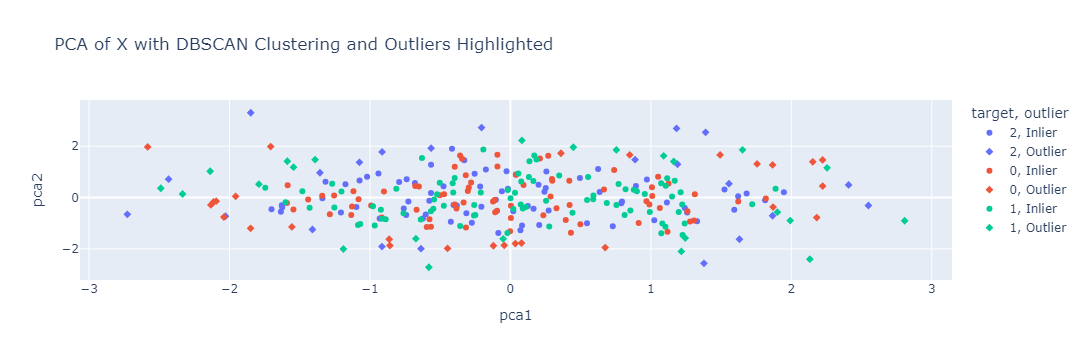

In [81]:
#@title 🚄 quick_pca

import pandas as pd
import numpy as np

def generate_dummy_data(n_samples=300, n_features=5, n_classes=3, random_state=42):
    """
    Generate a dummy dataset with the specified number of samples, features, and classes.

    Parameters:
    -----------
    n_samples : int
        The number of samples to generate.
    n_features : int
        The number of features for each sample.
    n_classes : int
        The number of distinct classes (categories) for the target variable.
    random_state : int
        The random seed for reproducibility.

    Returns:
    --------
    X : DataFrame
        The generated feature dataset as a Pandas DataFrame.
    y : Series
        The target variable with class labels.
    """
    np.random.seed(random_state)
    
    # Create feature data with a normal distribution
    X = np.random.randn(n_samples, n_features)
    
    # Create a target variable with discrete class labels
    y = np.random.randint(n_classes, size=n_samples)
    
    # Convert to Pandas DataFrame and Series
    feature_columns = [f'Feature_{i+1}' for i in range(n_features)]
    X_df = pd.DataFrame(X, columns=feature_columns)
    y_series = pd.Series(y, name='Target')
    
    return X_df, y_series

# Generate dummy data
X_dummy, y_dummy = generate_dummy_data()

# Now you can pass this data to your function
quick_pca(X_dummy, y_dummy)

C:\Users\Marek\AppData\Local\Temp\ipykernel_24424\735650338.py:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



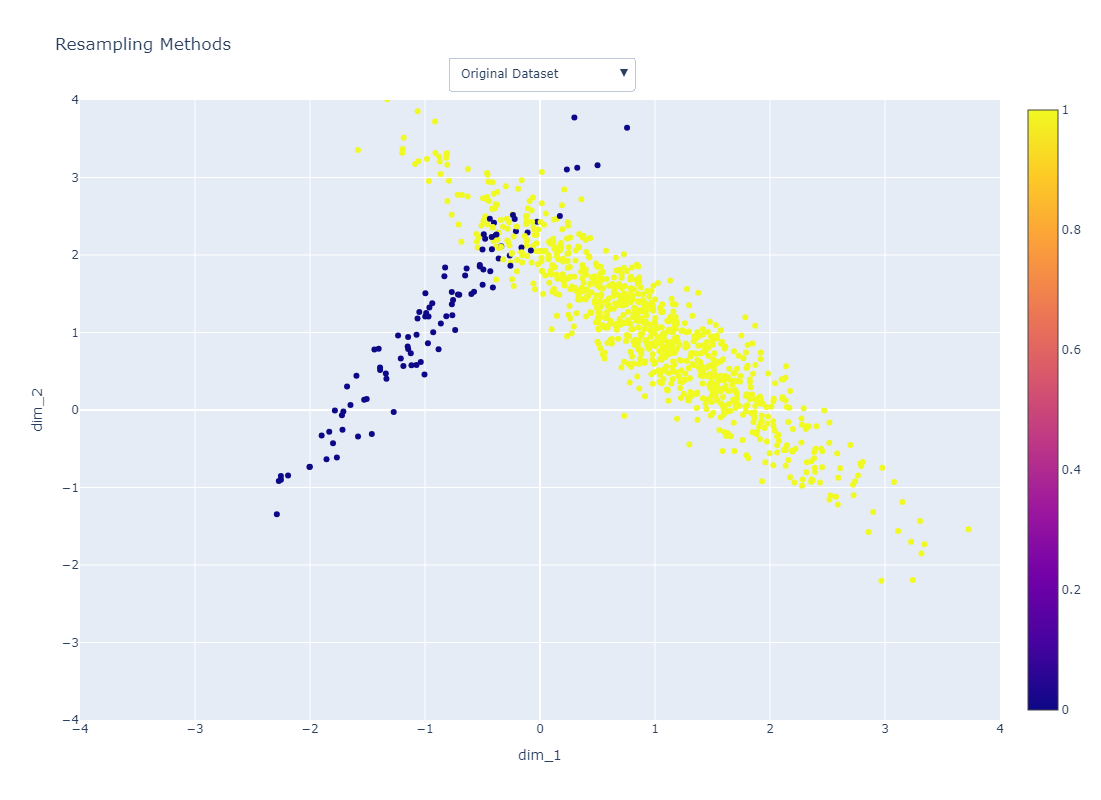

In [76]:
#@title ⚖️ imbalanced_resampling

import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks, ClusterCentroids, EditedNearestNeighbours
from imblearn.over_sampling import SMOTE, ADASYN
import plotly.graph_objects as go


# Step 1: Create a synthetic imbalanced dataset
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.1, 0.9], flip_y=0, random_state=42)

# Step 2: Apply resampling methods
resampling_methods = ['Original Dataset', 'RandomUnderSampler', 'NearMiss', 'TomekLinks', 'ClusterCentroids',
                      'EditedNearestNeighbors', 'SMOTE', 'ADASYN']

resampling_df = pd.DataFrame(columns=['dim_1', 'dim_2', 'y', 'method'])

# Append original dataset
original_df = pd.DataFrame(X, columns=['dim_1', 'dim_2'])
original_df['y'] = y
original_df['method'] = 'Original Dataset'
resampling_df = pd.concat([resampling_df, original_df])

# Append all resampling methods
for method in resampling_methods[1:]:  # Skip 'Original Dataset'
    single_resampling_df = pd.DataFrame(columns=['dim_1', 'dim_2', 'y', 'method'])
    X_resampled, y_resampled = imbalanced_resampling(X, y, method=method)
    single_resampling_df[['dim_1', 'dim_2']] = X_resampled
    single_resampling_df['y'] = y_resampled
    single_resampling_df['method'] = method
    resampling_df = pd.concat([resampling_df, single_resampling_df])

# Step 3: Visualize the results using scatter plots
# Create a scatter plot for each method
fig = go.Figure()

# Add a trace for each method
for method in resampling_methods:
    df_method = resampling_df[resampling_df['method'] == method]
    visible_state = True if method == "Original Dataset" else False  # Only show the original dataset by default
    fig.add_trace(go.Scatter(
        x=df_method['dim_1'],
        y=df_method['dim_2'],
        mode='markers',
        marker=dict(color=df_method['y'], showscale=True),
        name=method,
        visible=visible_state
    ))

# Create the buttons to switch between the different methods
buttons = []
for i, method in enumerate(resampling_methods):
    # Create a list of visibility states for all traces
    visibility = [False] * len(resampling_methods)
    visibility[i] = True  # Only the selected method will be visible
    button = dict(
        label=method,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Resampling Method: {method}"}]
    )
    buttons.append(button)

# Add buttons to the layout
fig.update_layout(
    updatemenus=[
        {
            "buttons": buttons,
            "direction": "down",
            "showactive": True,
            "x": 0.4,
            "y": 1.07,
            "xanchor": "left",
            "yanchor": "top"
        }
    ],
    title="Resampling Methods",
    xaxis_title="dim_1",
    yaxis_title="dim_2"
)

fig.update_layout(
    xaxis=dict(range=[-4, 4]),
    yaxis=dict(range=[-4, 4]),
    height=800,
    width=900
)

fig.show()

In [91]:
#@title 🪱 filter_outliers

sample_dataset = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/car_crashes.csv')
filter_outliers(sample_dataset, 'ins_premium', ratio=1, precision=2)
# https://github.com
# mwaskom/seaborn-data/blob/master/car_crashes.csv

Column: ins_premium valid range including IQR +/- (1 * STD): <528.92, 1247.46>
Removed 3 records, which is 5.88%


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL
10,15.6,2.964,3.900,14.820,14.508,913.15,142.80,GA


# 🏆Kaggle

In [93]:
#@title 🛠️ Imports
from pytka.kaggle import create_download_link, validate_kaggle_submission

In [94]:
#@title 🔗 create_download_link

data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia'],
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania'],
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155]
}

# Create the DataFrame
df = pd.DataFrame(data)

# Create a link

create_download_link(df)

In [100]:
#@title ✅ validate_kaggle_submission

# Create a sample submission DataFrame
sample_submission_df = pd.DataFrame({
    'Id': [1, 2, 3],
    'Prediction': [0.5, 0.3, 0.7]
})

# Scenario 1: Valid submission DataFrame (should pass validation)
valid_submission_df = pd.DataFrame({
    'Id': [4, 5, 6],
    'Prediction': [0.6, 0.4, 0.8]
})


# Scenario 2: Data type mismatch (should raise AssertionError)
dtype_mismatch_df = pd.DataFrame({
    'Id': ['4', '5', '6'],  # IDs are strings instead of integers
    'Prediction': [0.6, 0.4, 0.8]
})

# Scenario 3: Missing values (should raise AssertionError)
missing_values_df = pd.DataFrame({
    'Id': [4, 5, 6],
    'Prediction': [0.6, None, 0.8]  # Contains a None value
})

# Test each scenario
test_cases = [
    ("Valid Submission", valid_submission_df),
    ("Data Type Mismatch", dtype_mismatch_df),
    ("Missing Values", missing_values_df)
]

# Run validation tests
for test_name, df in test_cases:
    print(f"Test name: {test_name}")
    try:
        result = validate_kaggle_submission(df, sample_submission_df)
        print(f"{test_name}: Passed - {result}\n")
    except AssertionError as e:
        print(f"{test_name}: Failed - {str(e)}\n")

Test name: Valid Submission
Valid Submission: Passed - {'columns_match': True, 'dtypes_match': True, 'no_missing_values': True}

Test name: Data Type Mismatch
Data Type Mismatch: Failed - Data types mismatches between submissions

Test name: Missing Values
Missing Values: Failed - Nulls present in the submission



# ⏱️ Logging

In [2]:
#@title 🛠️ Imports

from pytka.logging import mlflow_experiment, step_time_calculation, list_devices

In [2]:
#@title 🤖 mlflow_experiment

import dagshub
import mlflow

# Provide your Dagshub / MLFLOW credentials to test the function

repo_name =  'dummy_repo' #@param {type:'string'}
user_name = 'markpyt1992' #@param {type:'string'}

dagshub.init(repo_name, user_name, mlflow=True)

# Part to train a dummy neural network
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_absolute_error


params = {'max_value': 10, 'no_of_values': 100, 'train_test_split': 0.8,
          'dense_units': 10, 'optimizer': 'adam', 'loss': 'mse', 'epochs':100}

@mlflow_experiment(experiment_name = 'dummy_training',
                   params = params)

def fit_dummy_neural_network(max_value=10, no_of_values=100, train_test_split=0.8,
                             dense_units=10, optimizer='adam', loss='mse',
                             epochs=100):

  # Generate synthetic linear data
  np.random.seed(42)
  X = np.linspace(0, max_value, no_of_values)
  y = 2.5 * X + np.random.normal(0, 1, X.shape)

  # Split the data into training and test sets
  train_size = int(train_test_split * len(X))
  X_train, X_test = X[:train_size], X[train_size:]
  y_train, y_test = y[:train_size], y[train_size:]

  # Build a basic neural network model
  model = Sequential([
      Dense(dense_units, input_dim=1, activation='relu'),
      Dense(1)
  ])

  # Compile the model
  model.compile(optimizer=optimizer, loss=loss)

  # Train the model
  model.fit(X_train, y_train, epochs=epochs, verbose=1)

  # Make predictions
  y_pred = model.predict(X_test)

  # Create metrics

  mae = mean_absolute_error(y_pred, y_test)
  metrics = {'mae': round(mae,4) }
  return model, metrics

fit_dummy_neural_network(**params)




❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=d727d383-864b-48de-9af1-e2edca92622d&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=00fe1d41996b082f6c4daa018a188a38d5ae83bdaaf8f0b61864128a33535aeb




Output()

Accessing as markpyt1992

Repository dummy_repo doesn't exist, creating it under current user.

...

Epoch 1/100


C:\Users\Marek\PycharmProjects\coolbox\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 122.5526  
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 114.1545 
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 130.4521 
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 127.2333 
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - loss: 126.3691
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 119.4140 
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 114.5835 
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 125.6094 
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 120.8710 
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 123.1863  
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 111.8318 
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 112.6352  
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 104.7768
Epoch 14/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 110.4457 
Epoch 15/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 109.6911  


2024/08/05 10:30:11 INFO mlflow.tracking._tracking_service.client: 🏃 View run resilient-sloth-650 at: https://dagshub.com/markpyt1992/dummy_repo.mlflow/#/experiments/0/runs/b533977e299c4584adfe6dc003d52d9f.
2024/08/05 10:30:11 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/markpyt1992/dummy_repo.mlflow/#/experiments/0.


(<Sequential name=sequential, built=True>, {'mae': 13.7887})

In [3]:
#@title 🦶 step_time_calculation

@step_time_calculation(step_name='long_dummy_function')
def long_dummy_function():
  for x in range(10**7):
    x

long_dummy_function()

Started execution of LONG_DUMMY_FUNCTION step
LONG_DUMMY_FUNCTION || Total execution time in seconds: 0.196783


In [3]:
#@title 🤖 list_devices

list_devices()

{'CPU': [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')],
 'GPU': [],
 'TPU': []}

# 💡Others

In [15]:
#@title 🛠️ Imports
from pytka.others import create_zip

In [19]:
#@title 🎁 create_zip

data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia'],
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania'],
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155]
}

# Create the DataFrame

df = pd.DataFrame(data)

df.to_csv('dummy_dataframe.csv')

create_zip(['dummy_dataframe.csv'], 'dummy_data.zip')


ZIP file: dummy_data.zip containing ['dummy_dataframe.csv'] generated successfully


# 🌐 Optuna

In [20]:
#@title 🛠️ Imports
from pytka.optuna import optuna_parallel_coordinates

[I 2024-08-05 11:18:11,274] A new study created in memory with name: no-name-c763d5ae-9daf-405f-94f5-9627b082f08c
[I 2024-08-05 11:18:11,274] Trial 0 finished with value: 0.5164078390401801 and parameters: {'x': 1.3473990927368735, 'y': -3.300865243721378}. Best is trial 0 with value: 0.5164078390401801.
[I 2024-08-05 11:18:11,274] Trial 1 finished with value: 101.47482036716238 and parameters: {'x': -7.801715170936139, 'y': -0.6759517915923645}. Best is trial 0 with value: 0.5164078390401801.
[I 2024-08-05 11:18:11,289] Trial 2 finished with value: 10.231056225640348 and parameters: {'x': 4.341177706616303, 'y': -0.8205635655786665}. Best is trial 0 with value: 0.5164078390401801.
[I 2024-08-05 11:18:11,290] Trial 3 finished with value: 187.02044312393986 and parameters: {'x': -9.788099174996974, 'y': -9.932615737539152}. Best is trial 0 with value: 0.5164078390401801.
[I 2024-08-05 11:18:11,290] Trial 4 finished with value: 110.08433930313896 and parameters: {'x': -6.928799119234467,

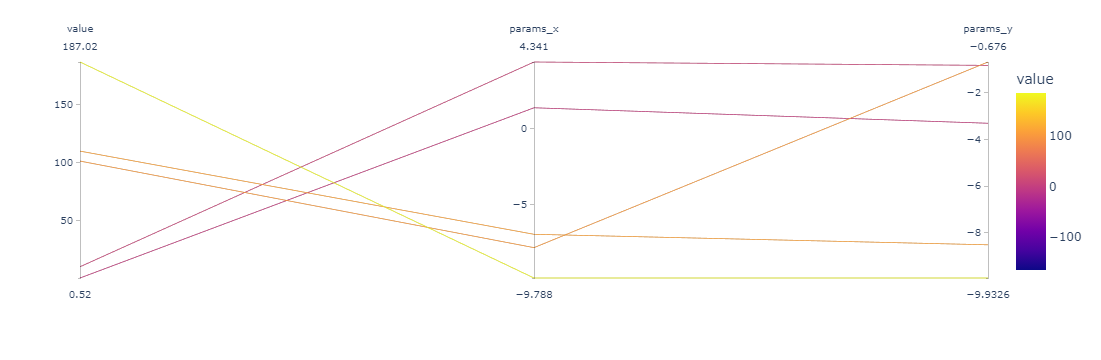

In [22]:
#@title 🦇 optuna_parallel_coordinates

def objective(trial):
  x = trial.suggest_float('x', -10, 10)
  y = trial.suggest_float('y', -10, 10)
  return (x - 2) ** 2 + (y + 3) ** 2

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

optuna_parallel_coordinates(study)

# 🎨 Plots

In [28]:
#@title 🛠️ Imports
from pytka.plots import make_html_filename, calculate_boxplot_stats

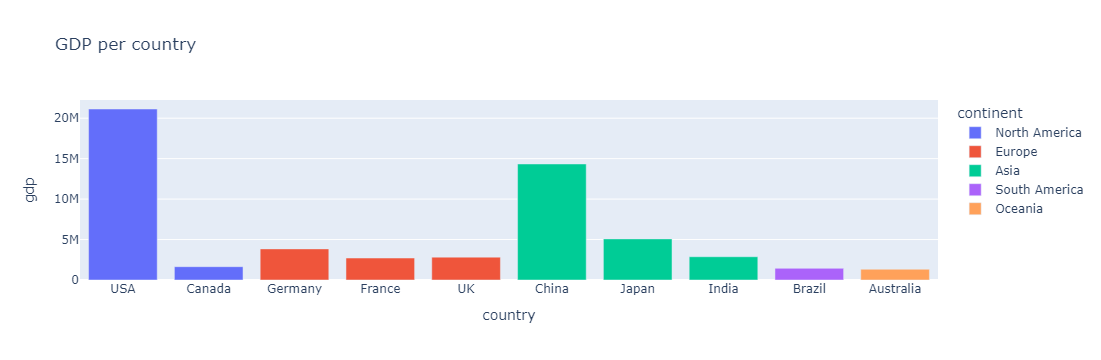

In [26]:
#@title 📊 make_html_filename

# Create proper data

data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia'],
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania'],
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155]
}

df = pd.DataFrame(data)

# Build a plot
plot_title = 'GDP per country'
fig = px.bar(df, x='country', y ='gdp', color='continent', title = plot_title)

# This cell drops a programming-friendly HTML filename into the runtime

fig.write_html(make_html_filename(plot_title))
fig.show()

In [29]:
#@title 📊 calculate_boxplot_stats

data = {
    'country': ['USA', 'Canada', 'Germany', 'France', 'UK', 'China', 'Japan', 'India', 'Brazil', 'Australia'],
    'continent': ['North America', 'North America', 'Europe', 'Europe', 'Europe', 'Asia', 'Asia', 'Asia', 'South America', 'Oceania'],
    'gdp': [21137518, 1647000, 3845630, 2715518, 2825208, 14342903, 5081770, 2875142, 1444731, 1330155]
}

df = pd.DataFrame(data)

calculate_boxplot_stats(data['gdp'])



Box({
    'lowerfence': [1330155],
    'mean': [5724557.5],
    'median': [2850175.0],
    'q1': [1914129.5],
    'q3': [4772735.0],
    'sd': [6289774.663273784],
    'upperfence': [21137518]
})

In [31]:
#@title 🧠 Neural Nets

from pytka.neural_nets import sparse_softmax

print('Regular softmax outputs')
print(sparse_softmax([1.0, 2.0, 3.0], k=1))
print('Sparse softmax outputs (k=2)')
sparse_softmax([1.0, 2.0, 3.0], k=2)


Regular softmax outputs
[0.16666666666666666, 0.3333333333333333, 0.5]
Sparse softmax outputs (k=2)


[0.07142857142857142, 0.2857142857142857, 0.6428571428571429]

Started execution of GLOBAL_DESCRIPTIVE_STATS step


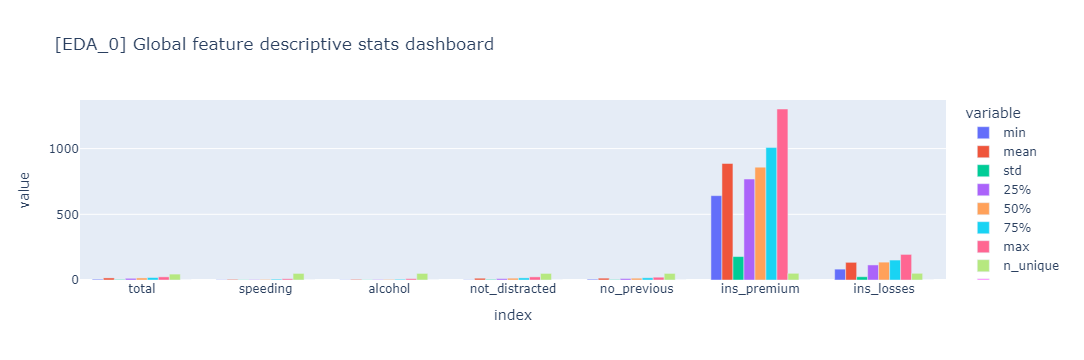

GLOBAL_DESCRIPTIVE_STATS || Total execution time in seconds: 0.056478
Started execution of FEATURE_BOXPLOTS step
Total features: 6
Grid size: 4 x 2
Processing feature: speeding which is 1 out of 6
Processing feature: alcohol which is 2 out of 6
Processing feature: not_distracted which is 3 out of 6
Processing feature: no_previous which is 4 out of 6
Processing feature: ins_premium which is 5 out of 6
Processing feature: ins_losses which is 6 out of 6


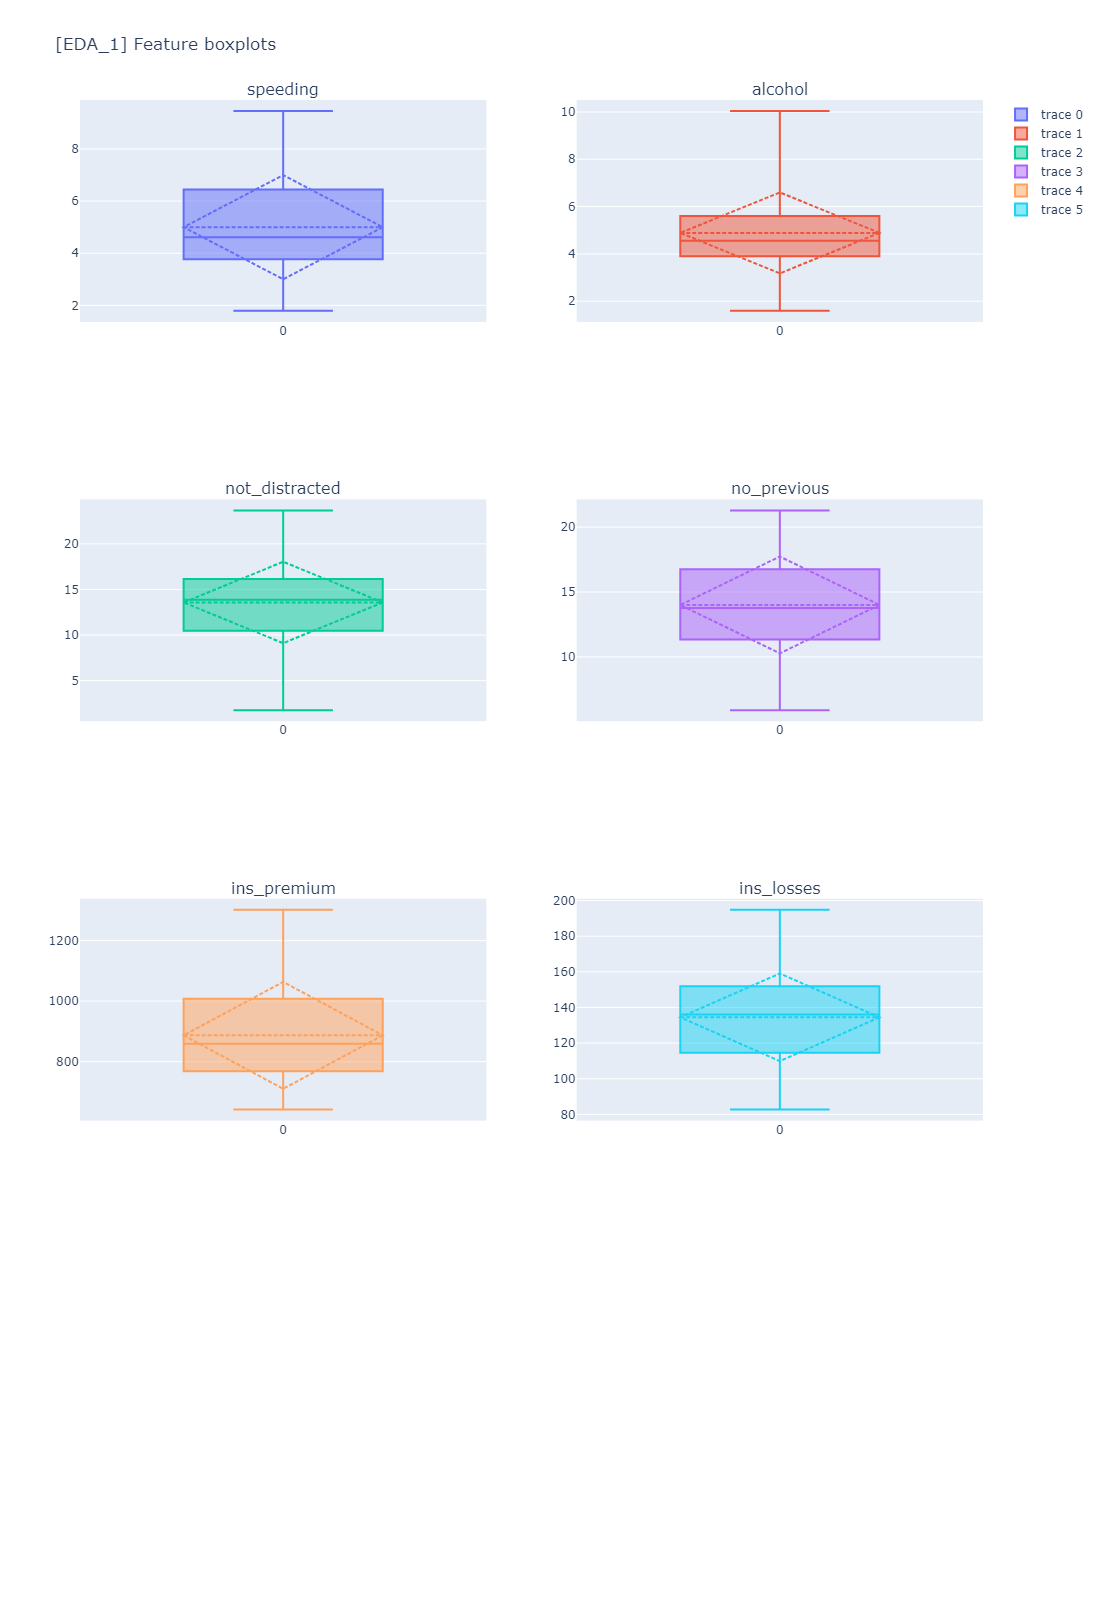

Plot [EDA_1] Feature boxplots generated successfully
FEATURE_BOXPLOTS || Total execution time in seconds: 0.056739
Started execution of FEATURE_CORRELATIONS step


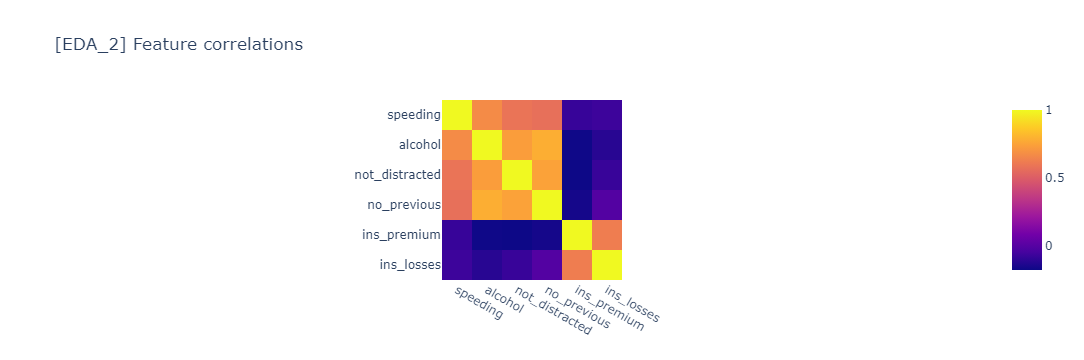

Plot [EDA_2] Feature correlations generated successfully
FEATURE_CORRELATIONS || Total execution time in seconds: 0.038134
Started execution of FEATURE_MEAN_TARGET step
Feature: speeding mean summary generated successfully
Feature: alcohol mean summary generated successfully
Feature: not_distracted mean summary generated successfully
Feature: no_previous mean summary generated successfully
Feature: ins_premium mean summary generated successfully
Feature: ins_losses mean summary generated successfully


C:\Users\Marek\PycharmProjects\coolbox\pytka\src\pytka\eda.py:87: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



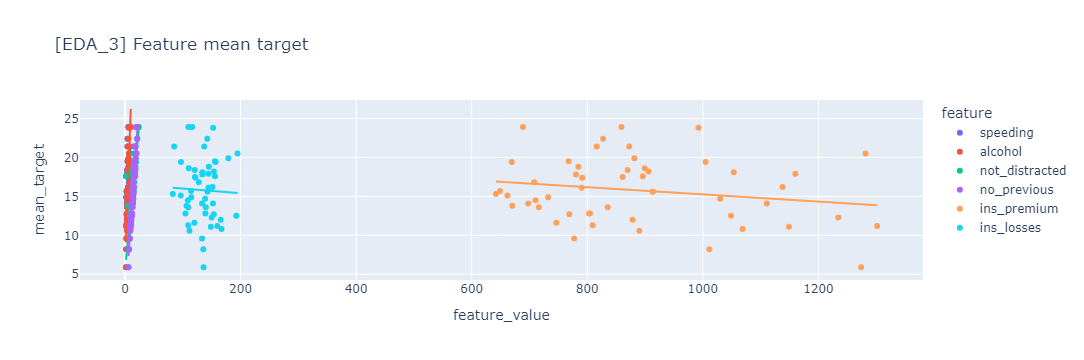

Plot [EDA_3] Feature mean target generated successfully
FEATURE_MEAN_TARGET || Total execution time in seconds: 0.079377
Started execution of FEATURE_LINEARITY step


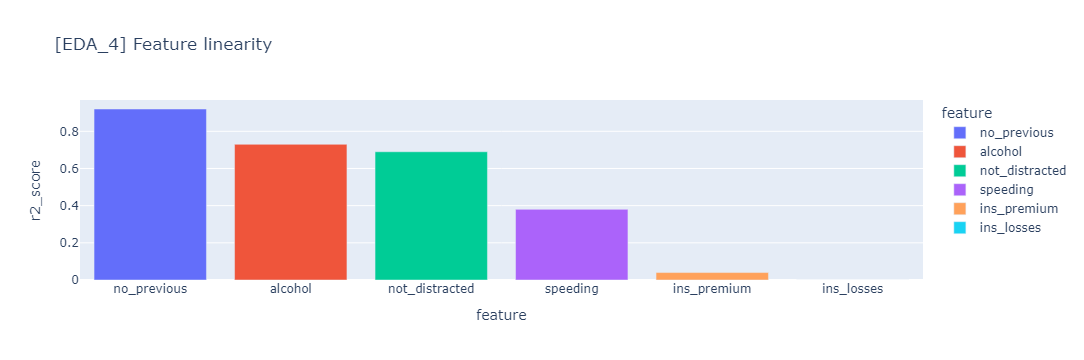

Plot [EDA_4] Feature linearity generated successfully
FEATURE_LINEARITY || Total execution time in seconds: 0.093897
Started execution of TARGET_BALANCE step


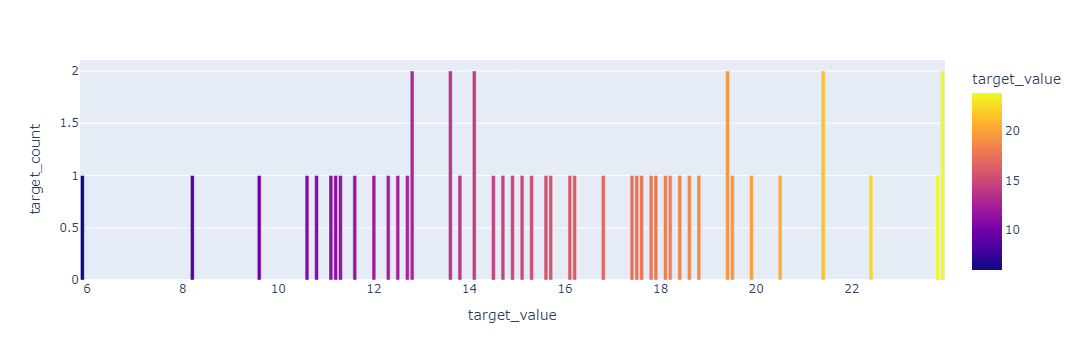

TARGET_BALANCE || Total execution time in seconds: 0.047303
Started execution of DETECT_OUTLIERS step
Column: alcohol expected range for ratio IQR +/- (1.0 * STDDEV): <2.18, 7.31>
Column: alcohol expected range for ratio IQR +/- (1.11 * STDDEV): <2.0, 7.5>
Column: alcohol expected range for ratio IQR +/- (1.22 * STDDEV): <1.81, 7.69>
Column: alcohol expected range for ratio IQR +/- (1.33 * STDDEV): <1.62, 7.88>
Column: alcohol expected range for ratio IQR +/- (1.44 * STDDEV): <1.43, 8.07>
Column: alcohol expected range for ratio IQR +/- (1.56 * STDDEV): <1.23, 8.27>
Column: alcohol expected range for ratio IQR +/- (1.67 * STDDEV): <1.04, 8.46>
Column: alcohol expected range for ratio IQR +/- (1.78 * STDDEV): <0.85, 8.65>
Column: alcohol expected range for ratio IQR +/- (1.89 * STDDEV): <0.66, 8.84>
Column: alcohol expected range for ratio IQR +/- (2.0 * STDDEV): <0.47, 9.02>


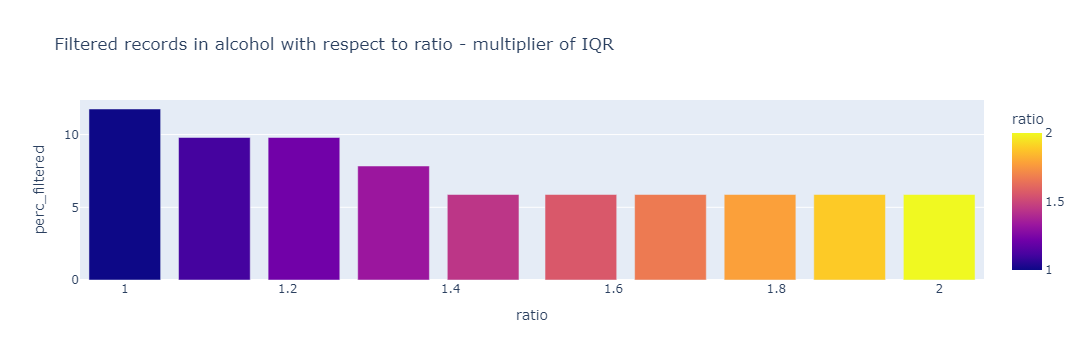

DETECT_OUTLIERS || Total execution time in seconds: 0.031615
Started execution of DETECT_OUTLIERS step
Column: ins_losses expected range for ratio IQR +/- (1.0 * STDDEV): <77.42, 189.1>
Column: ins_losses expected range for ratio IQR +/- (1.11 * STDDEV): <73.33, 193.19>
Column: ins_losses expected range for ratio IQR +/- (1.22 * STDDEV): <69.23, 197.28>
Column: ins_losses expected range for ratio IQR +/- (1.33 * STDDEV): <65.14, 201.38>
Column: ins_losses expected range for ratio IQR +/- (1.44 * STDDEV): <61.04, 205.47>
Column: ins_losses expected range for ratio IQR +/- (1.56 * STDDEV): <56.57, 209.94>
Column: ins_losses expected range for ratio IQR +/- (1.67 * STDDEV): <52.48, 214.04>
Column: ins_losses expected range for ratio IQR +/- (1.78 * STDDEV): <48.38, 218.13>
Column: ins_losses expected range for ratio IQR +/- (1.89 * STDDEV): <44.29, 222.23>
Column: ins_losses expected range for ratio IQR +/- (2.0 * STDDEV): <40.19, 226.32>


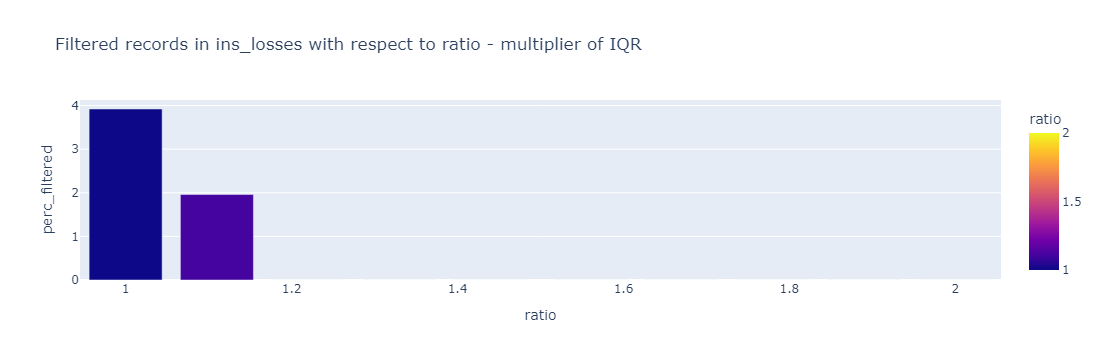

DETECT_OUTLIERS || Total execution time in seconds: 0.046884


,ratio,perc_filtered
0,1.00,3.92
1,1.11,1.96
2,1.22,0.00
3,1.33,0.00
4,1.44,0.00
5,1.56,0.00
6,1.67,0.00
7,1.78,0.00
8,1.89,0.00
9,2.00,0.00


In [9]:
#@title 💡 EDA

from pytka.eda import AutoEDA

sample_dataset = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/car_crashes.csv')

# Params for the class
skip_cols = ['abbrev'] # categoricals not supported yet
aggs = ['min', 'mean', 'std', '25%', '50%', '75%', 'max']
metrics = ['n_unique', 'nan_count']
target_col = 'total'

eda = AutoEDA(skip_cols=skip_cols, metrics=metrics, aggs=aggs, target_col=target_col, 
              dataframe=sample_dataset)

eda.global_descriptive_stats()
eda.feature_boxplots()
eda.feature_correlations()
eda.feature_mean_target()
eda.feature_linearity()
eda.target_balance()
eda.detect_outliers(column = 'alcohol', ratio_start=1, ratio_stop = 2)
eda.detect_outliers(column = 'ins_losses', ratio_start=1, ratio_stop=2)

In [7]:
#@title 🦍 Modelling

from pytka.modelling import UltimateClassifier,  train_catboost


Utilizing CPU for all trainings
Started execution of TRANSFORM_X step
TRANSFORM_X || Total execution time in seconds: 0.005592
Started execution of BUILD_TRAIN_SETS step
BUILD_TRAIN_SETS || Total execution time in seconds: 0.0
Started execution of FIT_MODELS step
Fitting ada_boost_classifier, which is 1 out of 10 models
Fitting bayes_classifier, which is 2 out of 10 models
Fitting catboost_classifier, which is 3 out of 10 models


C:\Users\Marek\PycharmProjects\coolbox\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



Fitting k_neighbors_classifier, which is 4 out of 10 models
Fitting lgbm_classifier, which is 5 out of 10 models
Fitting logreg_classifier, which is 6 out of 10 models
Fitting mlp_classifier, which is 7 out of 10 models


C:\Users\Marek\PycharmProjects\coolbox\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



Fitting random_forest_classifier, which is 8 out of 10 models
Fitting support_vector_classifier, which is 9 out of 10 models
Fitting xgboost_classifier, which is 10 out of 10 models
FIT_MODELS || Total execution time in seconds: 5.054867
Started execution of GENERATE_PREDICTIONS step
GENERATE_PREDICTIONS || Total execution time in seconds: 0.058207
Started execution of EXTEND_TRAINING_RECORDS step
EXTEND_TRAINING_RECORDS || Total execution time in seconds: 0.182079
Started execution of GENERATE_METRICS step
Average metrics generated using normalizer transformation
          measure_value
measure                
accuracy       0.985091
roc_auc        0.985067
GENERATE_METRICS || Total execution time in seconds: 0.15693


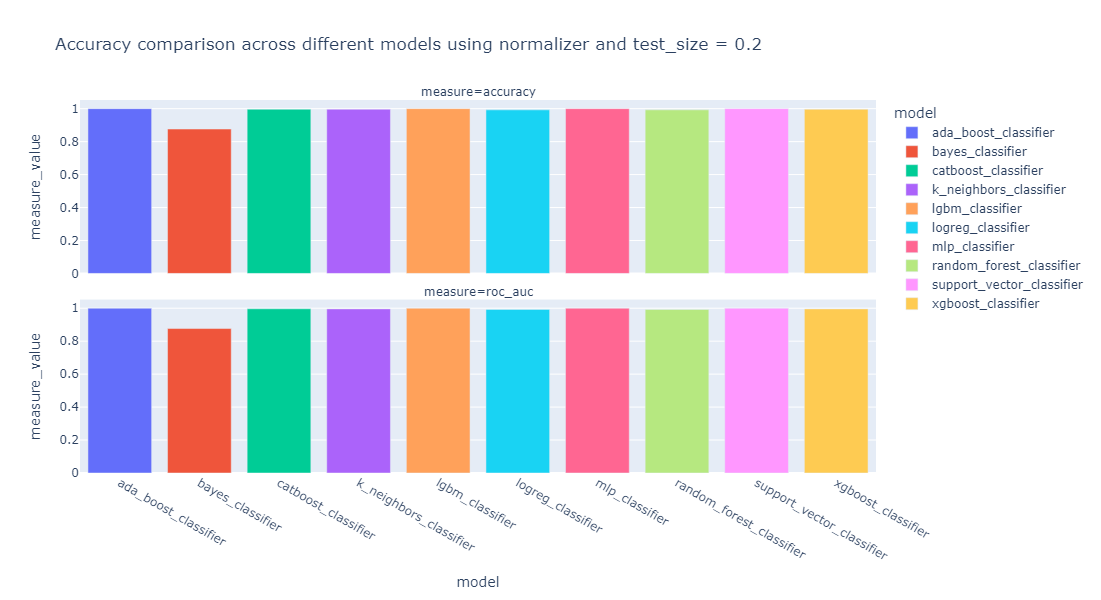

In [10]:
#@title 🏹 UltimateClassifier
#@markdown Add average metric for all models to see quickly which scaling works best 
banknotes_df = pd.read_csv('https://raw.githubusercontent.com/Kuntal-G/Machine-Learning/master/R-machine-learning/data/banknote-authentication.csv')

X = banknotes_df[['variance', 'skew', 'curtosis', 'entropy']]
y = banknotes_df['class']

ultimate_classifier = UltimateClassifier(X = X, y = y, scaling='normalizer', 
                                             test_size=0.2, use_gpu_if_available = True)

ultimate_classifier.transform_X()
ultimate_classifier.build_train_test_sets()
ultimate_classifier.fit_models()
ultimate_classifier.generate_predictions()
ultimate_classifier.extend_training_records()
# ultimate_classifier.blend_predictions() -- not super helpful (yet)
ultimate_classifier.generate_metrics(plot_height=600, plot_width=1000)

In [ ]:
#@title 😾 train_catboost

train_catboost(X, y, categorical_feats = None, params={'verbose':1}) 